# Exercícios - Dados do Bolsa Família (Visualizações com Matplotlib)

Lista de exercícios com foco em gráficos simples e respostas numéricas retiradas dos dados.


## DADOS

Os dados para essa atividade encontram-se em:

https://drive.google.com/file/d/13KRdiYnQikDx3pxPKGUTeejOz1fLHjzm/view?usp=sharing

In [ ]:
# Rodando arquivo anterior
%%capture
%run "Exercicio_1_BolsaFamilia_Metricas.ipynb"

In [ ]:
# Converte MES REFERENCIA de inteiro (YYYYMM) para datetime
df["MÊS REFERÊNCIA"] = pd.to_datetime(df["MÊS REFERÊNCIA"].astype(str), format='%Y%m')

display(df.head())
display(df.info())

,MÊS COMPETÊNCIA,MÊS REFERÊNCIA,UF,CÓDIGO MUNICÍPIO SIAFI,NOME MUNICÍPIO,CPF FAVORECIDO,NIS FAVORECIDO,NOME FAVORECIDO,VALOR PARCELA
0,202601,2026-01-01,BA,3641,ITIUBA,***.557.525-**,1.626318e+10,GERCINA SANTOS SOUZA,600.0
1,202601,2026-01-01,RJ,6001,RIO DE JANEIRO,***.986.507-**,1.648093e+10,LUCIANA DA SILVA FERREIRA,650.0
3,202601,2026-01-01,PB,1959,BREJO DOS SANTOS,***.577.104-**,1.606359e+10,KESILY PEREIRA DE MEDEIROS,750.0
4,202601,2026-01-01,GO,9489,NIQUELANDIA,***.672.381-**,2.106645e+10,AMANDA KARITA DA SILVA,800.0
5,202601,2026-01-01,RS,8801,PORTO ALEGRE,***.242.350-**,2.107894e+10,ANA MARIA MACHADO PADILHA,600.0


<class 'pandas.core.frame.DataFrame'>
Index: 6101351 entries, 0 to 7749666
Data columns (total 9 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   MÊS COMPETÊNCIA         int64         
 1   MÊS REFERÊNCIA          datetime64[ns]
 2   UF                      object        
 3   CÓDIGO MUNICÍPIO SIAFI  int64         
 4   NOME MUNICÍPIO          object        
 5   CPF FAVORECIDO          object        
 6   NIS FAVORECIDO          float64       
 7   NOME FAVORECIDO         object        
 8   VALOR PARCELA           float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 465.5+ MB


None

### Questão 1
Crie um **gráfico de barras** com a contagem de registros por `uf`. Depois, informe o **maior valor de contagem** (número inteiro).


784522

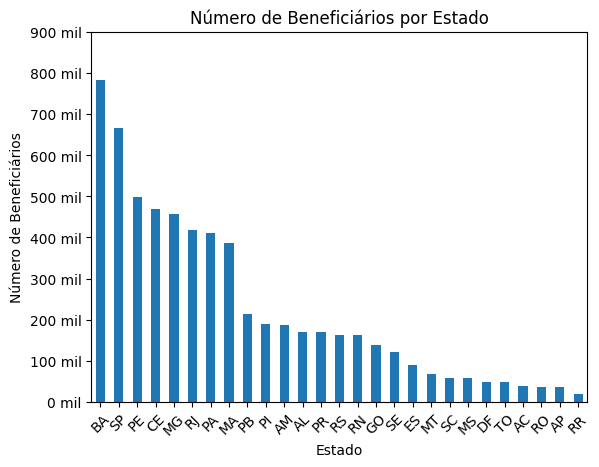

In [44]:
# Conta registros por UF, divide por 1000 para escala legivel e plota barras
import matplotlib.pyplot as plt
import seaborn as sns

(df["UF"].value_counts()/1_000).plot(kind="bar")
plt.title("Número de Beneficiários por Estado")
plt.xlabel("Estado")
plt.ylabel("Número de Beneficiários")
plt.xticks(rotation=45)
plt.yticks(plt.yticks()[0], [f"{int(num)} mil" for num in plt.yticks()[0]])
df["UF"].value_counts().max()

- O estado com maior numero de beneficiarios é a Bahia com 784522

### Questão 2
Crie um **gráfico de barras horizontal** com os 10 municípios com mais registros. Informe a **contagem do primeiro colocado** (número inteiro).


183048

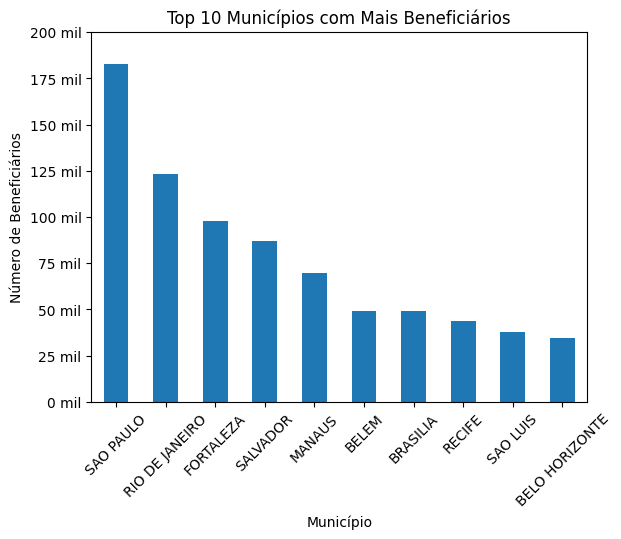

In [45]:
# Pega os 10 municipios mais frequentes e plota grafico de barras
(df['NOME MUNICÍPIO'].value_counts().head(10)/1_000).plot(kind='bar')
plt.title("Top 10 Municípios com Mais Beneficiários")
plt.xlabel("Município")
plt.ylabel("Número de Beneficiários")
plt.xticks(rotation=45)
plt.yticks(plt.yticks()[0], [f"{int(num)} mil" for num in plt.yticks()[0]])

df['NOME MUNICÍPIO'].value_counts().max()

- O municipio com maior numero de beneficiarios é a São Paulo com 183048

### Questão 3
Crie um **gráfico de barras** com a soma de `valor_parcela` por `uf`. Informe a **maior soma** (número decimal).


517254281.0

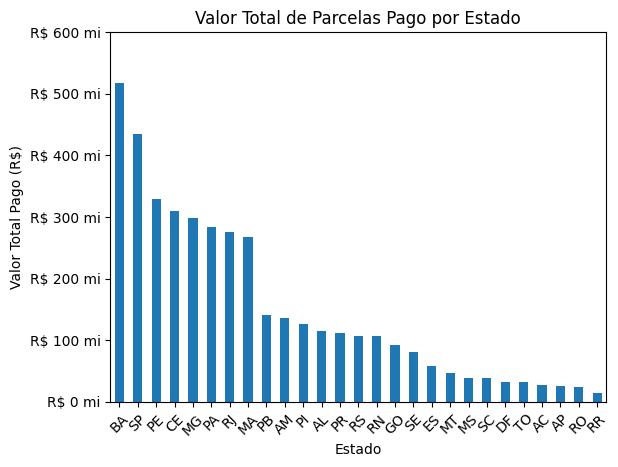

In [46]:
# Agrupa a soma de valor_parcela por mes e plota linha temporal
(df.groupby("UF")["VALOR PARCELA"].sum().sort_values(ascending=False)/1_000_000).plot(kind="bar")
plt.title("Valor Total de Parcelas Pago por Estado")
plt.xlabel("Estado")
plt.ylabel("Valor Total Pago (R$)")
plt.xticks(rotation=45)
plt.yticks(plt.yticks()[0], [f"R$ {int(num):,} mi".replace(",", ".") for num in plt.yticks()[0]])

df.groupby("UF")["VALOR PARCELA"].sum().max()

- O estado com maior valor total de parcelas é a Bahia com R$517.254.281,00

### Questão 4
Crie um **gráfico de linha** com a soma de `valor_parcela` por `mes_referencia` (em ordem crescente). Informe o **maior valor mensal** (número decimal).


C:\Users\cauan\AppData\Local\Temp\ipykernel_22344\2727106760.py:15: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_exclu = df[~df["MÊS REFERÊNCIA"].isin(['2026-01-01', '2025-02-01', '2025-05-01'])]


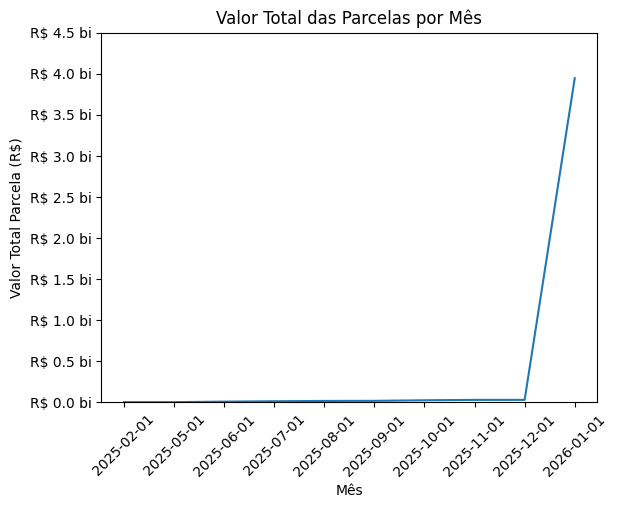

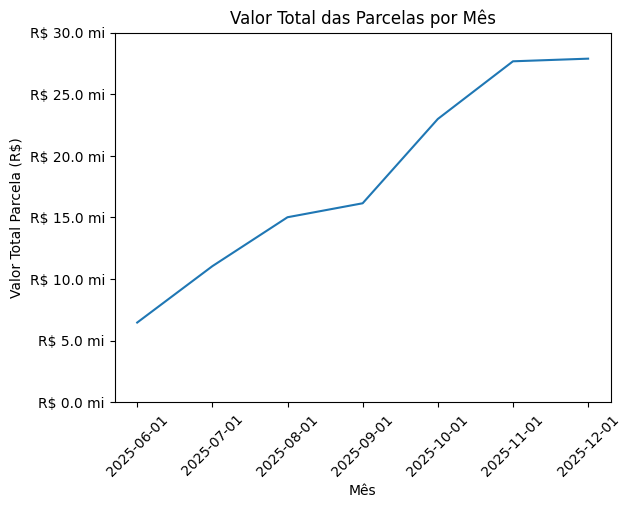

3944084496.0

In [ ]:
# Montando funcao pros graficos
def plot_mes(dados, titulo="Valor Total das Parcelas por Mês", divisor=1, sufixo=""):
    valor_mes = dados.groupby("MÊS REFERÊNCIA")["VALOR PARCELA"].sum() / divisor
    
    plt.plot(valor_mes.index.astype(str), valor_mes.values)
    plt.title(titulo)
    plt.xlabel("Mês")
    plt.ylabel("Valor Total Parcela (R$)")
    plt.xticks(rotation=45)
    plt.ylim(bottom=0)
    plt.yticks(plt.yticks()[0], [f"R$ {float(num):,} {sufixo}".replace(",", ".") for num in plt.yticks()[0]])
    
    plt.show()

df_exclu = df[~df["MÊS REFERÊNCIA"].isin(['2026-01-01', '2025-02-01', '2025-05-01'])]
# Grafico geral
plot_mes(df, divisor=1_000_000_000, sufixo="bi")

# Grafico sem outliers
plot_mes(df_exclu, divisor=1_000_000, sufixo="mi")

# Maximo
df.groupby("MÊS REFERÊNCIA")["VALOR PARCELA"].sum().max()


- O mes com maior valor total de parcelas foi o 2026/01 com R$3.944.084.496,00

### Questão 5
Crie um **gráfico de linha** com a contagem de registros por `mes_referencia`. Informe a **menor contagem mensal** (número inteiro).


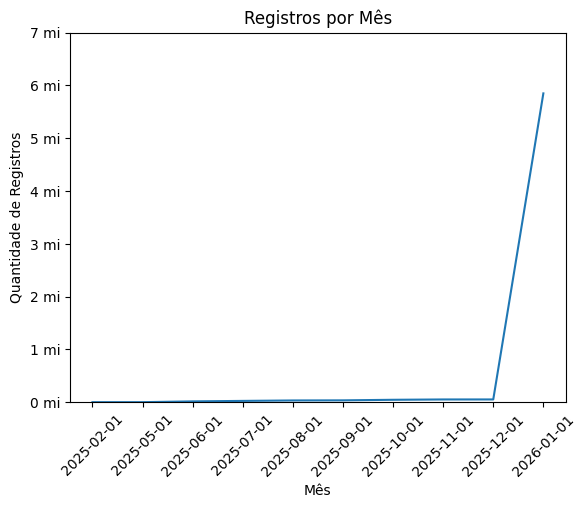

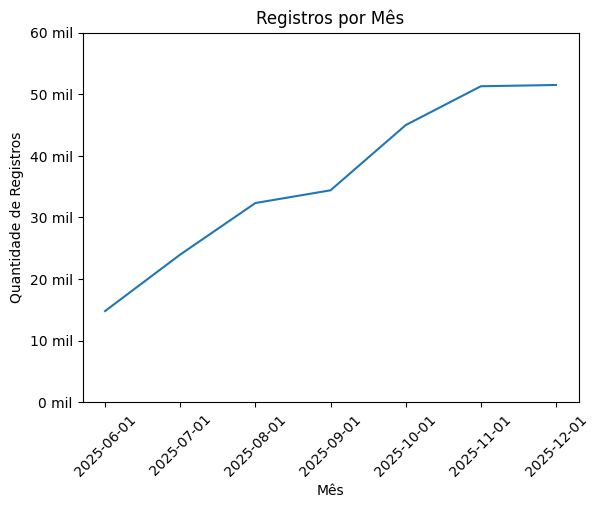

MÊS REFERÊNCIA
2025-02-01        1
2025-05-01        1
2025-06-01    14791
dtype: int64

In [ ]:
# Montando funcao dos graficos
def plot_mes(dados, titulo="Registros por Mês", divisor=1, sufixo=""):
    quant_mes = dados.groupby("MÊS REFERÊNCIA").size() / divisor
    
    plt.plot(quant_mes.index.astype(str), quant_mes.values)
    plt.title(titulo)
    plt.xlabel("Mês")
    plt.ylabel("Quantidade de Registros")
    plt.xticks(rotation=45)
    plt.ylim(bottom=0)
    plt.yticks(plt.yticks()[0], [f"{int(num):,} {sufixo}".replace(",", ".") for num in plt.yticks()[0]])
    
    plt.show()

# Grafico geral
plot_mes(df, divisor=1_000_000, sufixo="mi")

# Grafico sem outliers
plot_mes(df_exclu, divisor=1_000, sufixo="mil")

df.groupby("MÊS REFERÊNCIA").size().sort_values(ascending=True).head(3)


- Os meses com a menor quantidade de registros foram 2025/02 e 2025/05 apenas 1 

### Questão 6
Crie um **histograma** de `valor_parcela` (`bins=8`). Informe a **frequência da classe mais alta** (número inteiro).


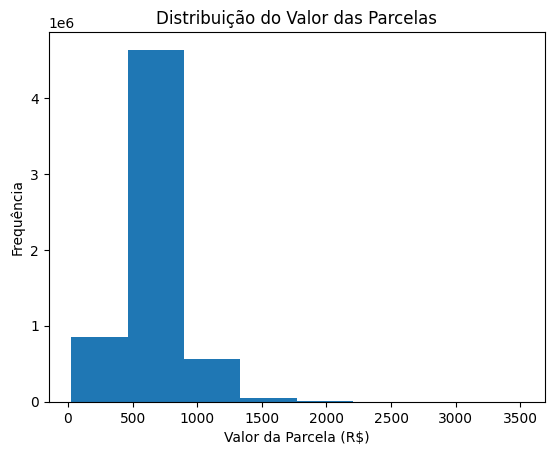

array([461.125, 897.25 ])

4635140

In [49]:
# Histograma com 8 bins - retorna frequencias e limites de cada classe
freq, lim, _= plt.hist(df['VALOR PARCELA'], bins=8)
plt.title("Distribuição do Valor das Parcelas")
plt.xlabel("Valor da Parcela (R$)")
plt.ylabel("Frequência")
plt.show()

display(lim[[1,2]])
display(int(freq.max()))

- A classe com maior frequencia é a de aproximadamente 450 a 900 tendo 4635140 ocorrencias

### Questão 7
Crie um **histograma** de `valor_parcela` e desenhe linhas verticais para média e mediana. Informe os dois valores: **média** e **mediana** (números decimais).


667.2742254953042
650.0


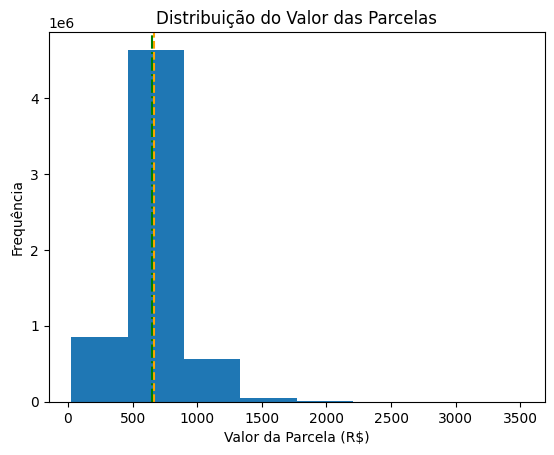

In [50]:
# Mesmo histograma com linhas verticais de media e mediana sobrepostas
media_parcela = df['VALOR PARCELA'].mean()
mediana_parcela = df['VALOR PARCELA'].median()

freq, lim, _= plt.hist(df['VALOR PARCELA'], bins=8)
plt.title("Distribuição do Valor das Parcelas")
plt.xlabel("Valor da Parcela (R$)")
plt.ylabel("Frequência")
plt.axvline(media_parcela,   color='orange', linestyle='--', linewidth=1.5)
plt.axvline(mediana_parcela, color='green',  linestyle='-.', linewidth=1.5)

print(media_parcela)
print(mediana_parcela)


- Os valores de media e mediana de valor de parcela sao R$667,27 e R$650 respectivamentes

### Questão 8
Crie um **boxplot** geral de `valor_parcela`. Em seguida, calcule e informe **Q1, mediana e Q3** (números decimais).


0.25    600.0
0.50    650.0
0.75    750.0
Name: VALOR PARCELA, dtype: float64

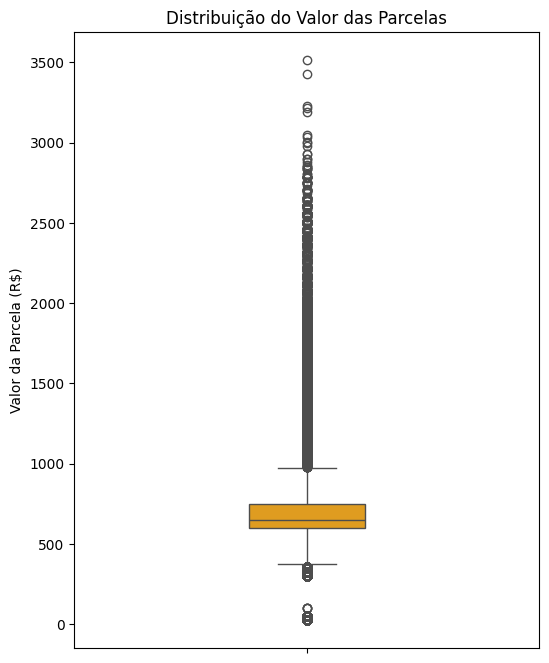

In [51]:
# Boxplot simples de valor_parcela e calculo dos quartis Q1, Q2, Q3
plt.figure(figsize=(6,8))
sns.boxplot(data=df['VALOR PARCELA'], color="orange", width=0.25)
plt.title("Distribuição do Valor das Parcelas")
plt.ylabel("Valor da Parcela (R$)")

df['VALOR PARCELA'].quantile([0.25,0.5,0.75])

- Os valores dos quartis sao R$600 e R$650 e R$750 respectivamentes

### Questão 9
Crie um **boxplot por `uf`** (use as 5 UFs com mais registros). Informe a **maior mediana entre as UFs** (número decimal).


BA:650.0
SP:650.0
PE:650.0
CE:650.0
MG:650.0


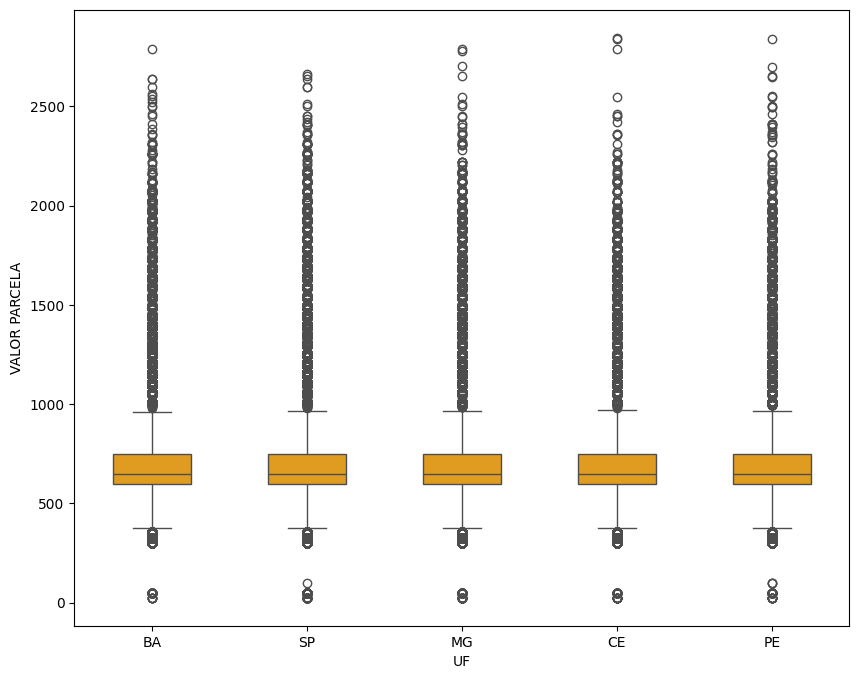

In [52]:
# Filtra as 5 UFs com mais registros e plota um boxplot por UF
top5_uf = df['UF'].value_counts().head()
df_uf = df[df['UF'].isin(top5_uf.index.tolist())].copy()
plt.figure(figsize=(10,8))
sns.boxplot(x='UF', y='VALOR PARCELA', data=df_uf, color='orange', width=0.5)
for i, uf in enumerate(top5_uf.index.tolist()):
    print(f'{uf}:{df_uf["VALOR PARCELA"].median()}')

- A mediana de todos os 5 estados com mais registros é R$650

### Questão 10
Crie um **gráfico de dispersão** com `mes_referencia` no eixo X e `valor_parcela` no eixo Y. Calcule e informe a **correlação de Pearson** (número decimal).


0.1709432003225579

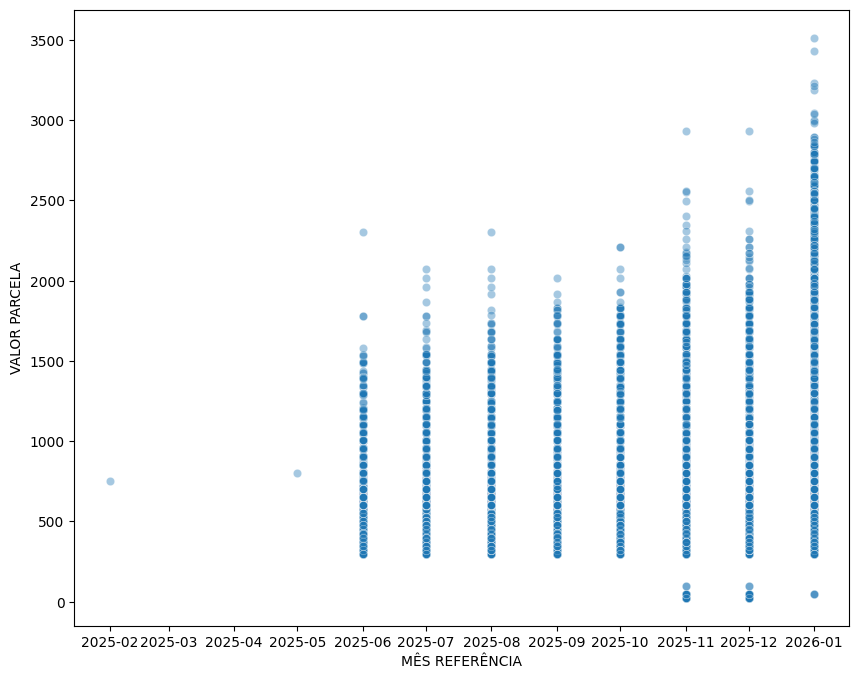

In [53]:
# Scatter de mes x valor_parcela com alpha para visualizar sobreposicao
from seaborn import color_palette
import matplotlib.dates as mdate

plt.figure(figsize=(10,8))
sns.scatterplot(x='MÊS REFERÊNCIA', y='VALOR PARCELA', data=df, alpha=0.4)
plt.gca().xaxis.set_major_locator(mdate.MonthLocator(interval=1))
df['MÊS REFERÊNCIA'].corr(df['VALOR PARCELA'])


- A correlação de person é aproximadamente 0,17

### Questão 11
Crie um **gráfico de barras** com a contagem de `nome_favorecido` distintos por `uf`. Informe a **maior contagem** (número inteiro).


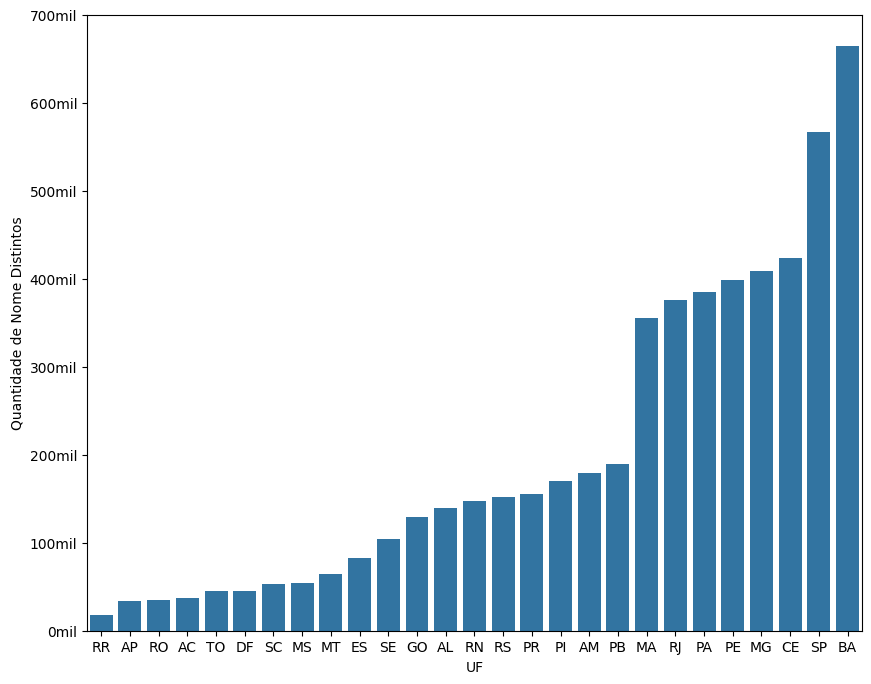

663970

In [54]:
# Conta nomes distintos por UF com nunique() e plota barras ordenadas
plt.figure(figsize=(10,8))
nome_por_uf = df.groupby("UF")["NOME FAVORECIDO"].nunique()
sns.barplot(nome_por_uf.sort_values(ascending=True)/1_000)
plt.ylabel('Quantidade de Nome Distintos')
plt.yticks(plt.yticks()[0], [f"{int(num):,}mil" for num in plt.yticks()[0]])
plt.show()
display(nome_por_uf.max())


- A Bahia é o estado com mais nomes distintos, com 663970 nomes

### Questão 12
Crie um **gráfico de pizza** da participação da soma de `valor_parcela` por `uf` (top 5 + Outros). Informe o **percentual da maior fatia** (número decimal).


0.5356570906606102

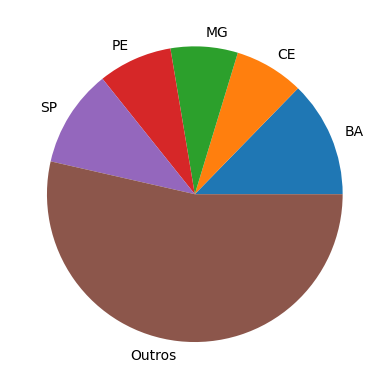

In [55]:
# Calcula soma por UF para top 5 + resto como Outros, plota pizza
from pandas import Index
df_uf_pizza = df_uf.groupby("UF")["VALOR PARCELA"].sum().reset_index()
df_outros = pd.DataFrame({"UF":"Outros",'VALOR PARCELA':[df["VALOR PARCELA"].sum() - df_uf["VALOR PARCELA"].sum()]})
df_uf_pizza = pd.concat([df_uf_pizza, df_outros])

plt.pie(df_uf_pizza["VALOR PARCELA"], labels=df_uf_pizza["UF"])
df_outros["VALOR PARCELA"].sum()/df["VALOR PARCELA"].sum()


- A maior fatia é os outros, compondo 53,56% aproximadamente

### Questão 13
Considere apenas municípios com pelo menos 2 registros. Crie um **gráfico de barras** da média de `valor_parcela` por município. Informe a **maior média** (número decimal).


NOME MUNICÍPIO
UIRAMUTA    1087.992175
Name: VALOR PARCELA, dtype: float64

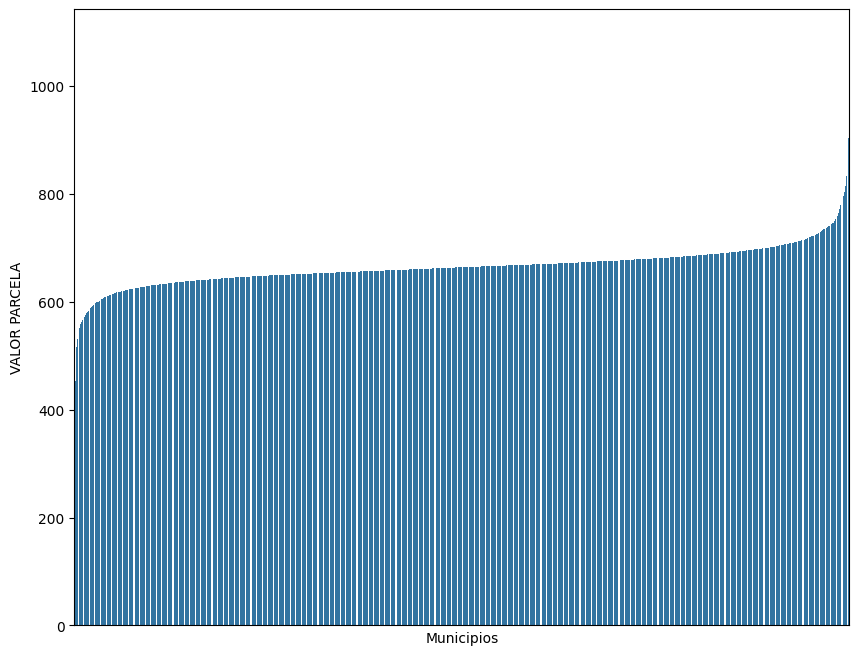

In [56]:
# Filtra municipios com mais de 1 registro, calcula media e plota barras
df_media_muni = df[df["NOME MUNICÍPIO"].map(df["NOME MUNICÍPIO"].value_counts() > 1)].groupby("NOME MUNICÍPIO")["VALOR PARCELA"].mean().sort_values(ascending=True)
plt.figure(figsize=(10,8))
sns.barplot(df_media_muni)
plt.xlabel("Municipios")
plt.xticks([])

display(df.groupby("NOME MUNICÍPIO")["VALOR PARCELA"].mean().sort_values(ascending=True).tail(1))

- O municipio com a maior media de parcela é Uiramuta com R$1087,99 de media

### Questão 14
Monte uma matriz (UF x `mes_referencia`) com contagem de registros e exiba em **heatmap com `imshow`**. Informe a **maior contagem de uma célula** (número inteiro).


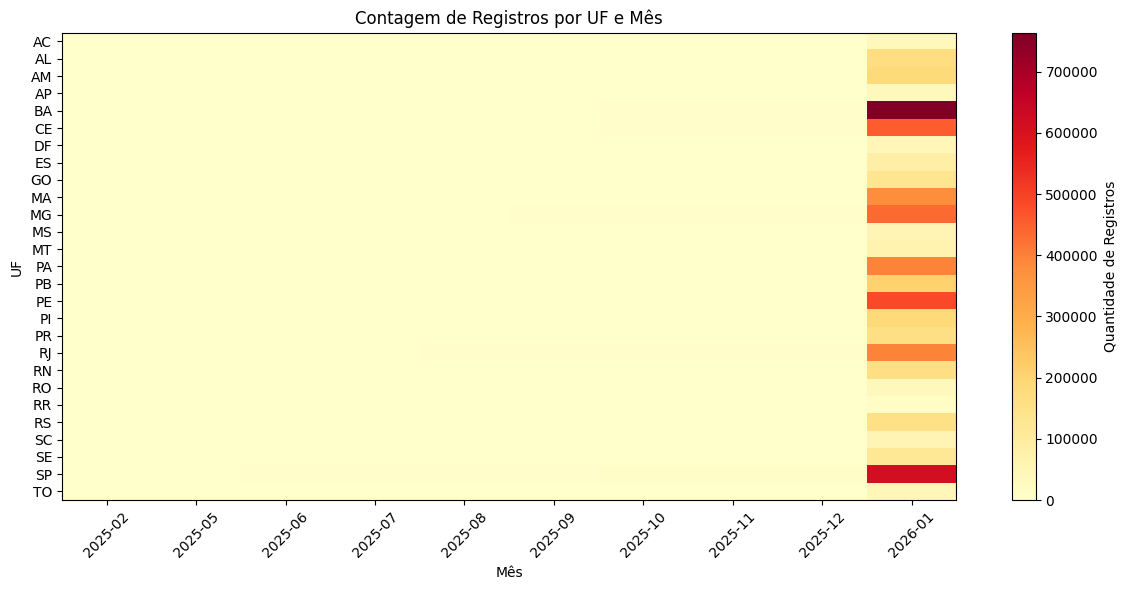

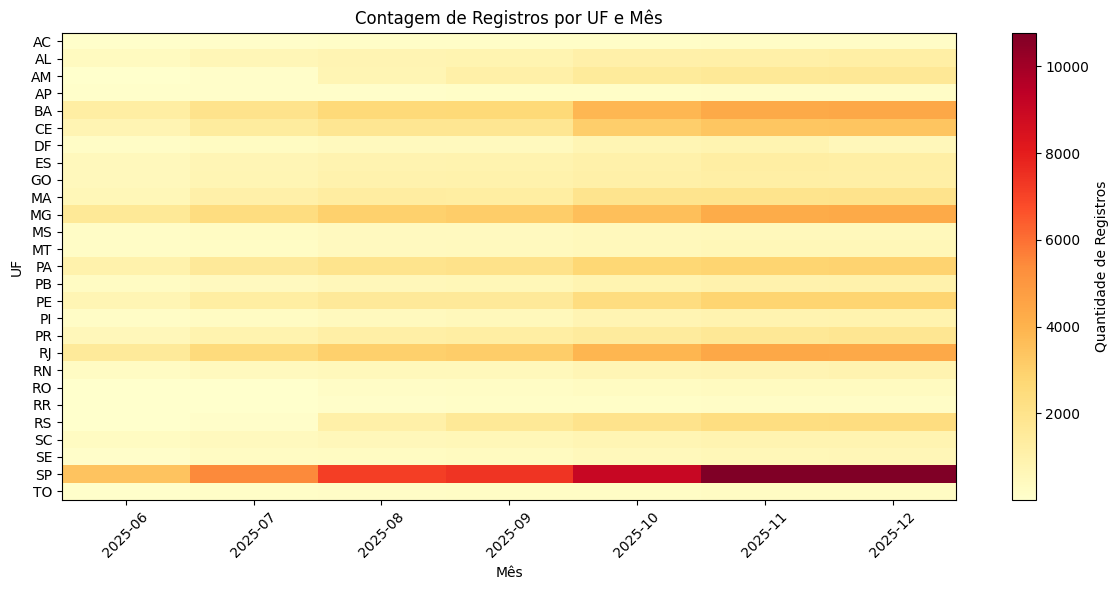

763478

('BA', Timestamp('2026-01-01 00:00:00'))

In [57]:
# Funcao que monta matriz UF x Mes com crosstab e exibe heatmap com imshow
def plot_heatmap_uf_mes(dados, titulo="Contagem de Registros por UF e Mês"):
    matriz = pd.crosstab(dados["UF"], dados["MÊS REFERÊNCIA"].dt.to_period("M"))

    plt.figure(figsize=(12, 6))
    plt.imshow(matriz, cmap="YlOrRd", aspect="auto")
    plt.colorbar(label="Quantidade de Registros")
    plt.title(titulo)
    plt.xlabel("Mês")
    plt.ylabel("UF")
    plt.xticks(range(len(matriz.columns)), matriz.columns, rotation=45)
    plt.yticks(range(len(matriz.index)), matriz.index)
    plt.tight_layout()
    plt.show()

plot_heatmap_uf_mes(df)
plot_heatmap_uf_mes(df_exclu)


display(matriz.stack().max())
display(matriz.stack().idxmax())

- 763478 foi a maior contagem de registros, na Bahia em 2026/01

### Questão 15
Crie um **gráfico de linha acumulado** da soma de `valor_parcela` por `mes_referencia`. Informe o **valor acumulado final** (número decimal).


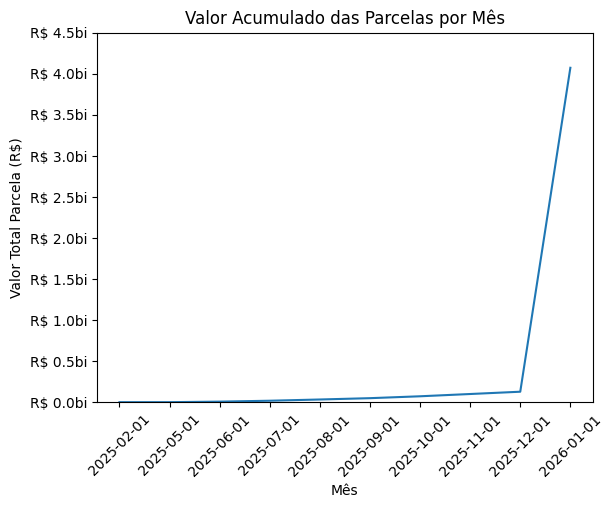

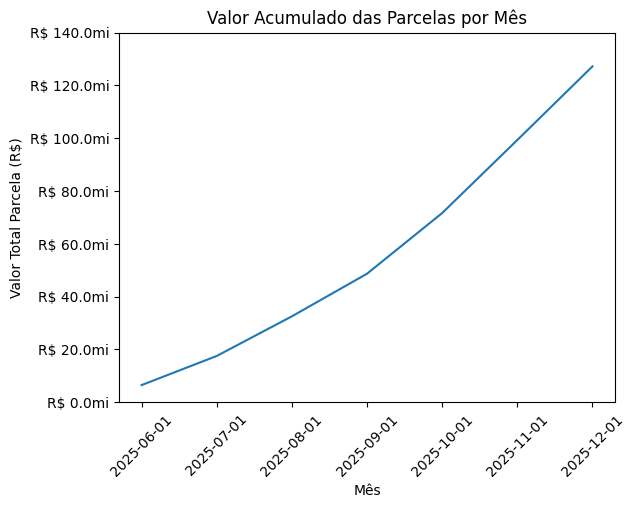

4071274263.0

In [58]:
# Funcao que acumula a soma mensal com cumsum() e plota linha acumulada
def plot_mes_acul(dados, titulo="Valor Acumulado das Parcelas por Mês", divisor=1, sufixo=""):
    valor_mes_acul = dados.groupby("MÊS REFERÊNCIA")["VALOR PARCELA"].sum() / divisor
    valor_mes_acul = valor_mes_acul.cumsum()
        
    plt.plot(valor_mes_acul.index.astype(str), valor_mes_acul.values)
    plt.title(titulo)
    plt.xlabel("Mês")
    plt.ylabel("Valor Total Parcela (R$)")
    plt.xticks(rotation=45)
    plt.ylim(bottom=0)
    plt.yticks(plt.yticks()[0], [f"R$ {float(num):,}{sufixo}".replace(",", ".") for num in plt.yticks()[0]])
    
    plt.show()
    
plot_mes_acul(df, divisor=10**9, sufixo="bi")
plot_mes_acul(df_exclu, divisor=10**6, sufixo="mi")

display(df.groupby("MÊS REFERÊNCIA")["VALOR PARCELA"].sum().sum())

- O valor total das parcelas foi de R$4.071.274.263,00